In [1]:
# Cel (23.08.2026, na prosbe Maćka): zamiast pojedynczej liczby (Spearman rho
# z 20260823a.ipynb) - bezposrednia heatmapa SUROWEGO KRAJOBRAZU sily efektu,
# osie: os X = t0 (lata od poczatku cyklu, zeby cykle o roznej dlugosci byly
# WIZUALNIE POROWNYWALNE panel-do-panelu), os Y = P_days (8 wartosci z
# gridu 1675..4000), kolor = MEDIANA (po 5 stacjach reprezentatywnych)
# -log10(PPDF). Osobny panel per cykl (6: 5 pelnych + cycle_2019_incomplete
# jako bonus - "gdzie jestesmy teraz", niepelny grid P_days dla niego).
#
# Dlaczego "lata od poczatku cyklu", nie data kalendarzowa: to bezposrednio
# odpowiada na pytanie z 20260823a.ipynb (czy "goracy" obszar sily efektu
# siedzi w tym samym MIEJSCU WZGLEDEM FAZY CYKLU u wszystkich 5 cykli, czy
# nie) - przy wspolnej osi lat-od-startu mozna to ocenic wzrokiem, panel
# obok panelu, zamiast tylko przez pojedyncza liczbe rho.
#
# ZERO nowych obliczen - to samo zrodlo co 20260823a.ipynb
# (results/cycle_scan_*.csv + results/pgrid_scan_*.csv), tylko inna
# wizualizacja. Wspolny colorbar dla wszystkich paneli (ta sama konwencja co
# 20260822d.ipynb pkt 17 dziennika 22.08 - kolory porownywalne miedzy
# panelami). Gwiazdka = globalne maksimum sily efektu w danym panelu
# (analogicznie do "*" w cycle_scan_heatmap.png, ale tam oznaczalo "bije
# benchmark referencyjny"; tutaj po prostu najsilniejszy punkt w cyklu).
import glob
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "../results"
STATIONS_5 = ["mosc", "oulu", "athn", "hrms", "sopb"]

# Granice cykli - identyczne jak w 20260822g.ipynb / 20260823a.ipynb
# (LOWESS frac=0.01 + find_peaks na SN_m_tot_V2.0.csv, obciete do zakresu
# katalogu EQ 1965-01-01..2025-01-31). Tym razem WLACZAMY cycle_2019_incomplete.
CYCLE_BOUNDS = {
    "cycle_1964": ("1965-01-01", "1976-02-01"),
    "cycle_1976": ("1976-02-01", "1986-05-01"),
    "cycle_1986": ("1986-05-01", "1996-06-01"),
    "cycle_1996": ("1996-06-01", "2008-11-01"),
    "cycle_2008": ("2008-11-01", "2019-09-01"),
    "cycle_2019_incomplete": ("2019-09-01", "2025-01-31"),
}
CYCLE_START = {c: pd.Timestamp(s) for c, (s, e) in CYCLE_BOUNDS.items()}
CYCLE_END = {c: pd.Timestamp(e) for c, (s, e) in CYCLE_BOUNDS.items()}
CYCLE_LENGTH_DAYS = {c: (CYCLE_END[c] - CYCLE_START[c]).days for c in CYCLE_BOUNDS}
for c, days in CYCLE_LENGTH_DAYS.items():
    print(f"{c}: {days} dni ({days/365.25:.2f} lat)")

cycle_1964: 4048 dni (11.08 lat)
cycle_1976: 3742 dni (10.25 lat)
cycle_1986: 3684 dni (10.09 lat)
cycle_1996: 4536 dni (12.42 lat)
cycle_2008: 3956 dni (10.83 lat)
cycle_2019_incomplete: 1979 dni (5.42 lat)


In [2]:
# Wczytanie WSZYSTKICH wynikow (cycle_scan_* + pgrid_scan_*) dla 5 stacji
# reprezentatywnych, WSZYSTKIE 6 segmentow cykli (w tym niepelny 2019).
FILENAME_RE = re.compile(
    r"^(?P<prefix>cycle_scan|pgrid_scan)_(?P<station>[a-z]+)_(?P<cycle>cycle_\d{4}(?:_incomplete)?)_P(?P<Pdays>\d+)_d(?P<d>\d+)\.csv$"
)


def parse_result_filename(path):
    m = FILENAME_RE.match(os.path.basename(path))
    if not m or m["station"] not in STATIONS_5 or m["cycle"] not in CYCLE_BOUNDS:
        return None
    return dict(station=m["station"], cycle=m["cycle"], P_days=int(m["Pdays"]), d=int(m["d"]))


frames = []
paths = sorted(glob.glob(os.path.join(RESULTS_DIR, "cycle_scan_*.csv")) +
                glob.glob(os.path.join(RESULTS_DIR, "pgrid_scan_*.csv")))
for path in paths:
    meta = parse_result_filename(path)
    if meta is None:
        continue
    df = pd.read_csv(path, usecols=["t0", "PPDF"], parse_dates=["t0"]).dropna(subset=["PPDF"])
    if len(df) == 0:
        continue
    df["station"] = meta["station"]
    df["cycle"] = meta["cycle"]
    df["P_days"] = meta["P_days"]
    df["d"] = meta["d"]
    frames.append(df)

all_candidates = pd.concat(frames, ignore_index=True)
print(f"Wczytano {len(all_candidates)} wierszy z {len(frames)} plikow")
for cycle in CYCLE_BOUNDS:
    p_days_here = sorted(all_candidates.loc[all_candidates.cycle == cycle, "P_days"].unique())
    print(f"  {cycle}: P_days dostepne = {p_days_here}")

Wczytano 1196172 wierszy z 344 plikow
  cycle_1964: P_days dostepne = [np.int64(1675), np.int64(2100), np.int64(2515), np.int64(2930), np.int64(3350), np.int64(3600), np.int64(3800), np.int64(4000)]
  cycle_1976: P_days dostepne = [np.int64(1675), np.int64(2100), np.int64(2515), np.int64(2930), np.int64(3350), np.int64(3600), np.int64(3800), np.int64(4000)]
  cycle_1986: P_days dostepne = [np.int64(1675), np.int64(2100), np.int64(2515), np.int64(2930), np.int64(3350), np.int64(3600), np.int64(3800), np.int64(4000)]
  cycle_1996: P_days dostepne = [np.int64(1675), np.int64(2100), np.int64(2515), np.int64(2930), np.int64(3350), np.int64(3600), np.int64(3800), np.int64(4000)]
  cycle_2008: P_days dostepne = [np.int64(1675), np.int64(2100), np.int64(2515), np.int64(2930), np.int64(3350), np.int64(3600), np.int64(3800), np.int64(4000)]
  cycle_2019_incomplete: P_days dostepne = [np.int64(1675)]


In [3]:
# Budowa macierzy heatmapy dla jednego cyklu: wiersze = P_days (dostepne dla
# tego cyklu), kolumny = wspolna dzienna os "lat od poczatku cyklu" (krok
# 24h, jak T0_STEP w skanie). Wartosc = MEDIANA -log10(PPDF) po stacjach,
# ktore maja dane w danym (P_days, t0). Brak danych (stacja/cykl/P_days poza
# zasiegiem) -> NaN -> biale pole na wykresie, tak jak w
# 20260822f.ipynb build_heatmap_matrix.
def build_cycle_heatmap(cycle, d):
    cyc = all_candidates[(all_candidates["cycle"] == cycle) & (all_candidates["d"] == d)]
    p_days_values = sorted(cyc["P_days"].unique())
    t0_ref = pd.date_range(CYCLE_START[cycle], CYCLE_END[cycle], freq="24h")
    years_since_start = (t0_ref - CYCLE_START[cycle]).days / 365.25

    mat = np.full((len(p_days_values), len(t0_ref)), np.nan)
    for i, P_days in enumerate(p_days_values):
        sub = cyc[cyc["P_days"] == P_days]
        med_ppdf = sub.groupby("t0")["PPDF"].median().reindex(t0_ref)
        with np.errstate(divide="ignore"):
            mat[i] = -np.log10(np.clip(med_ppdf.to_numpy(dtype=float), 1e-300, None))
    return p_days_values, years_since_start, mat


# Podglad zakresu kolorow (do wspolnego vmin/vmax per wykres d=1/d=5).
def global_vmax(d):
    vmax = 0.0
    for cycle in CYCLE_BOUNDS:
        _, _, mat = build_cycle_heatmap(cycle, d)
        if np.isfinite(mat).any():
            vmax = max(vmax, np.nanmax(mat))
    return vmax


VMAX_D1 = global_vmax(1)
VMAX_D5 = global_vmax(5)
print(f"vmax d=1: {VMAX_D1:.2f}, vmax d=5: {VMAX_D5:.2f}")

vmax d=1: 9.14, vmax d=5: 7.94


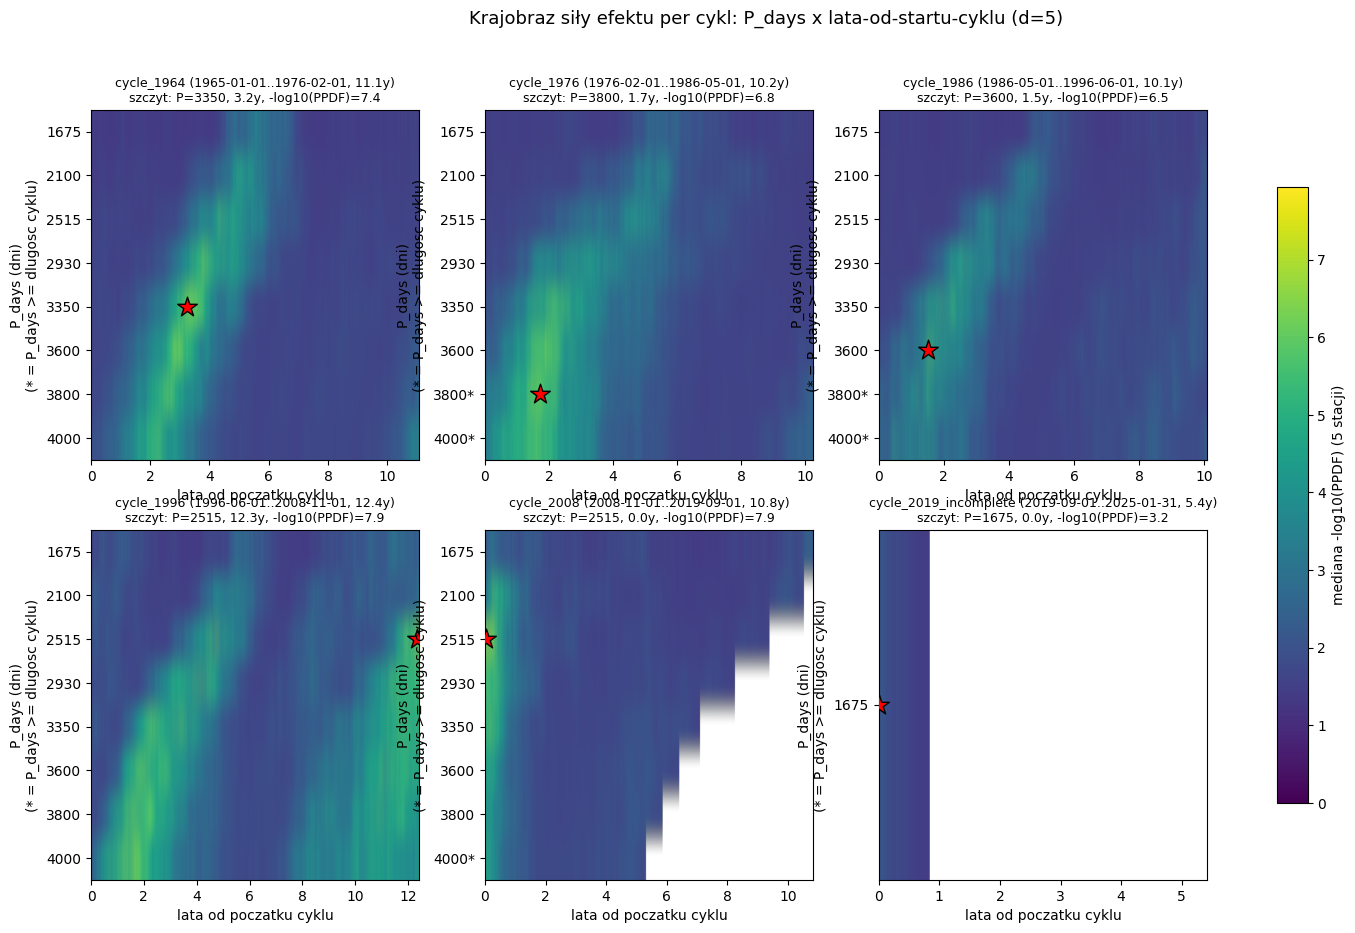

In [4]:
# GLOWNA FUNKCJA RYSUJACA: siatka 2x3 (6 cykli, chronologicznie), jeden
# wspolny colorbar. Gwiazdka = globalne maksimum mediany sily efektu w danym
# panelu (P_days, lata-od-startu, wartosc -log10(PPDF) w podpisie panelu).
# Y-tick etykiety P_days pogrubione, jesli dana wartosc P_days >= wlasnej
# dlugosci cyklu (P_days "wystaje" poza caly cykl) - wizualny kontekst do
# porownania z wynikiem 20260823a.ipynb (frakcja wlasnej dlugosci cyklu).
def plot_cycle_heatmaps(d, vmax, save_suffix):
    cycles_order = list(CYCLE_BOUNDS.keys())
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    im = None
    for ax, cycle in zip(axes.flat, cycles_order):
        p_days_values, years, mat = build_cycle_heatmap(cycle, d)
        if len(p_days_values) == 0:
            ax.set_visible(False)
            continue
        im = ax.imshow(
            mat, aspect="auto", cmap="viridis", vmin=0, vmax=vmax,
            extent=[years.min(), years.max(), len(p_days_values) - 0.5, -0.5],
        )
        ax.set_yticks(range(len(p_days_values)))
        ax.set_yticklabels(
            [f"{p}{'*' if p >= CYCLE_LENGTH_DAYS[cycle] else ''}" for p in p_days_values]
        )
        ax.set_ylim(len(p_days_values) - 0.5, -0.5)

        if np.isfinite(mat).any():
            flat_i = np.nanargmax(mat)
            pi, ti = np.unravel_index(flat_i, mat.shape)
            peak_val = mat[pi, ti]
            ax.scatter([years[ti]], [pi], marker="*", s=220, color="red", edgecolor="black", zorder=5)
            peak_note = f"szczyt: P={p_days_values[pi]}, {years[ti]:.1f}y, -log10(PPDF)={peak_val:.1f}"
        else:
            peak_note = "brak danych"

        length_y = CYCLE_LENGTH_DAYS[cycle] / 365.25
        ax.set_title(
            f"{cycle} ({CYCLE_START[cycle].date()}..{CYCLE_END[cycle].date()}, {length_y:.1f}y)\n{peak_note}",
            fontsize=9,
        )
        ax.set_xlabel("lata od poczatku cyklu")
        ax.set_ylabel("P_days (dni)\n(* = P_days >= dlugosc cyklu)")

    for ax in axes.flat[len(cycles_order):]:
        ax.set_visible(False)
    if im is not None:
        fig.colorbar(im, ax=axes, label="mediana -log10(PPDF) (5 stacji)", shrink=0.8)
    fig.suptitle(f"Krajobraz siły efektu per cykl: P_days x lata-od-startu-cyklu (d={d})", fontsize=13)
    fig.savefig(f"{RESULTS_DIR}/pgrid_heatmap_by_cycle_{save_suffix}.png", dpi=120, bbox_inches="tight")
    plt.show()


plot_cycle_heatmaps(5, VMAX_D5, "d5")

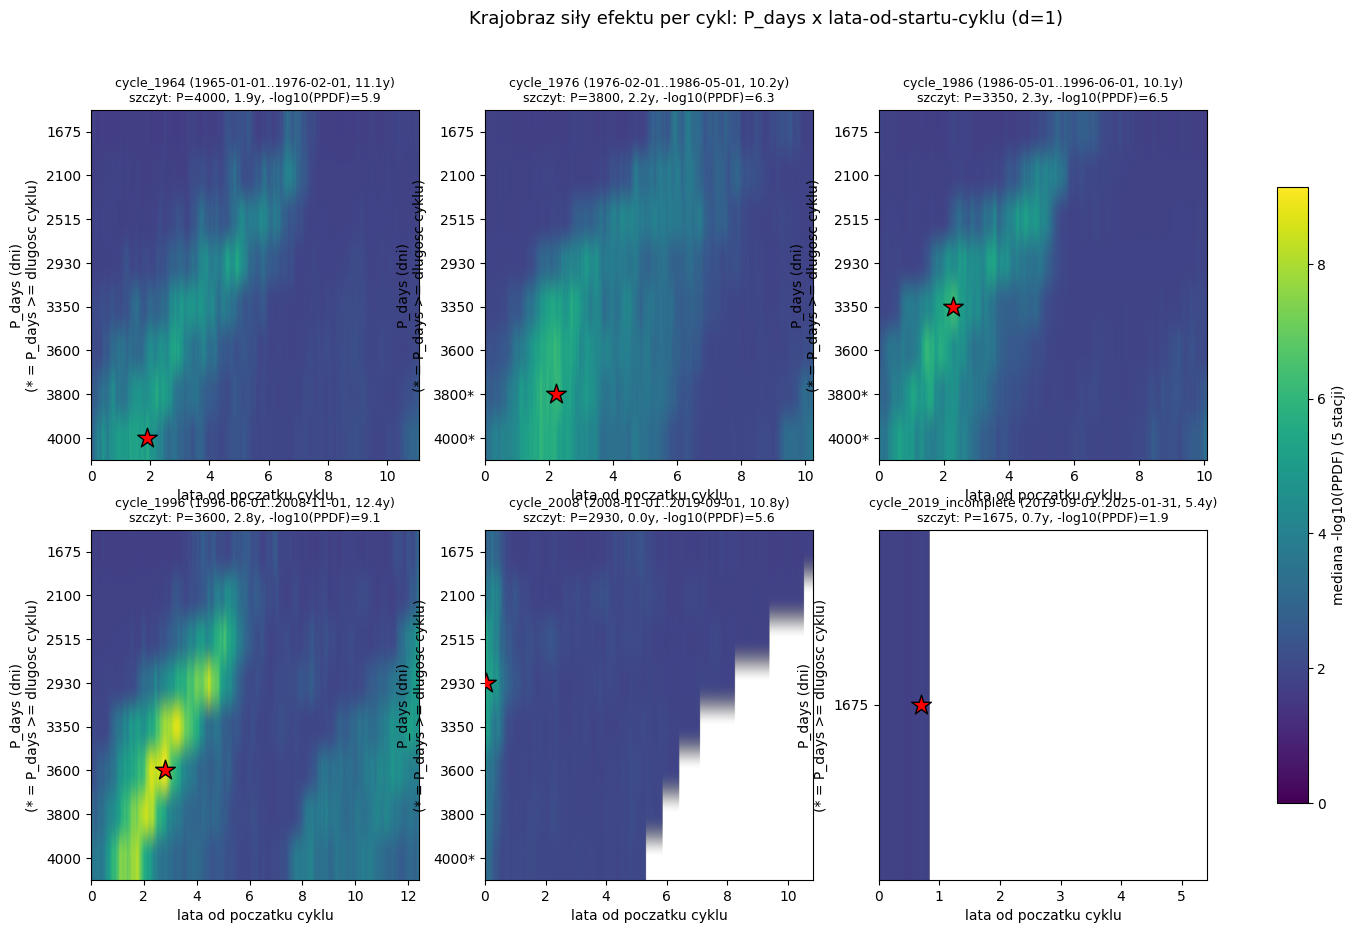

In [5]:
# To samo dla d=1 (kontrola przy innej szerokosci binu).
plot_cycle_heatmaps(1, VMAX_D1, "d1")